In [3]:
import pandas as pd

#load datasets
train_df = pd.read_csv('/Users/joshbuck/ClinicalMeetingRecorder/ClinicalMeetingRecorder/data/raw/MTS-Dialog-TrainingSet.csv')
val_df = pd.read_csv('/Users/joshbuck/ClinicalMeetingRecorder/ClinicalMeetingRecorder/data/raw/MTS-Dialog-ValidationSet.csv')

print(f'training samples: {len(train_df)}')
print(f'validation samples: {len(val_df)}')
print(f'\nColumns: {list(train_df.columns)}')
train_df.head()

training samples: 1201
validation samples: 100

Columns: ['ID', 'section_header', 'section_text', 'dialogue']


,ID,section_header,section_text,dialogue
0,0,GENHX,The patient is a 76-year-old white female who ...,Doctor: What brings you back into the clinic t...
1,1,GENHX,The patient is a 25-year-old right-handed Cauc...,Doctor: How're you feeling today? \r\nPatient...
2,2,GENHX,"This is a 22-year-old female, who presented to...","Doctor: Hello, miss. What is the reason for yo..."
3,3,MEDICATIONS,Prescribed medications were Salmeterol inhaler...,Doctor: Are you taking any over the counter me...
4,4,CC,"Burn, right arm.","Doctor: Hi, how are you? \r\nPatient: I burned..."


In [7]:
#how many unique section types are there?
#how often does each appear?
print('Section header counts:\n')
print(train_df['section_header'].value_counts())
print(f"\nTotal unique sections: {train_df['section_header'].nunique()}")

Section header counts:

section_header
FAM/SOCHX        351
GENHX            282
PASTMEDICALHX    118
CC                77
PASTSURGICAL      63
ALLERGY           60
ROS               60
MEDICATIONS       54
ASSESSMENT        34
EXAM              23
DIAGNOSIS         19
DISPOSITION       15
PLAN              11
EDCOURSE           8
IMMUNIZATIONS      8
IMAGING            6
GYNHX              5
PROCEDURES         3
OTHER_HISTORY      2
LABS               2
Name: count, dtype: int64

Total unique sections: 20


In [8]:
#see one full diagloge and note section
sample = train_df.iloc[0]
print("=== SECTION TYPE ===")
print(sample['section_header'])
print("\n=== DIALOGUE ===")
print(sample['dialogue'][:500])
print("\n=== CLINICAL NOTE SECTION ===")
print(sample['section_text'])

=== SECTION TYPE ===
GENHX

=== DIALOGUE ===
Doctor: What brings you back into the clinic today, miss? 
Patient: I came in for a refill of my blood pressure medicine. 
Doctor: It looks like Doctor Kumar followed up with you last time regarding your hypertension, osteoarthritis, osteoporosis, hypothyroidism, allergic rhinitis and kidney stones.  Have you noticed any changes or do you have any concerns regarding these issues?  
Patient: No. 
Doctor: Have you had any fever or chills, cough, congestion, nausea, vomiting, chest pain, chest 

=== CLINICAL NOTE SECTION ===
The patient is a 76-year-old white female who presents to the clinic today originally for hypertension and a med check.  She has a history of hypertension, osteoarthritis, osteoporosis, hypothyroidism, allergic rhinitis and kidney stones.  Since her last visit she has been followed by Dr. Kumar.  Those issues are stable.  She has had no fever or chills, cough, congestion, nausea, vomiting, chest pain, chest pressure.


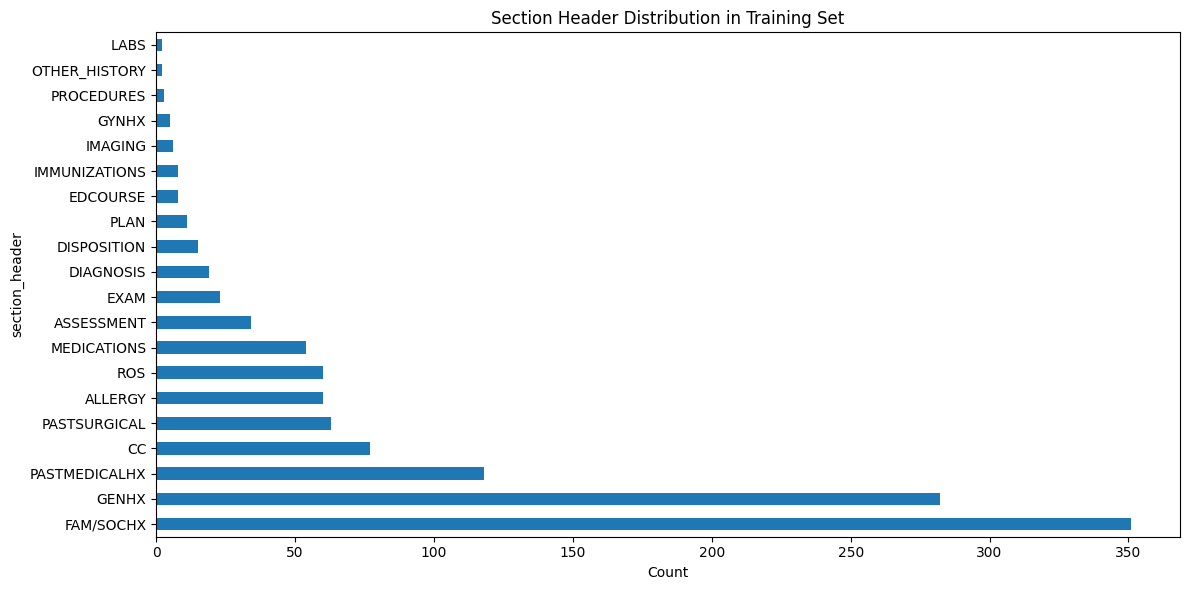

In [9]:
import matplotlib.pyplot as plt

#plot the distribution
fig, ax = plt.subplots(figsize=(12, 6))
train_df['section_header'].value_counts().plot(kind='barh', ax=ax)
ax.set_xlabel('Count')
ax.set_title('Section Header Distribution in Training Set')
plt.tight_layout()
plt.show()

In [10]:
#check unique dialogues vs total rows
print(f"Unique dialogues: {train_df['dialogue'].nunique()}")
print(f"\nSo on average, each dialogue maps to {len(train_df) / train_df['dialogue'].nunique():.1f} section(s)")

Unique dialogues: 1199

So on average, each dialogue maps to 1.0 section(s)


In [11]:
#dialogue and note length analysis

train_df['dialogue_word_count'] = train_df['dialogue'].str.split().str.len()
train_df['note_word_count'] = train_df['section_text'].str.split().str.len()
train_df['dialogue_turn_count'] = train_df['dialogue'].str.count(r'Doctor:|Patient:')

print("=== DIALOGUE LENGTH (words) ===")
print(train_df['dialogue_word_count'].describe().round(1))
print("\n=== NOTE LENGTH (words) ===")
print(train_df['note_word_count'].describe().round(1))
print("\n=== TURNS PER DIALOGUE ===")
print(train_df['dialogue_turn_count'].describe().round(1))

=== DIALOGUE LENGTH (words) ===
count    1201.0
mean      105.7
std       117.6
min         6.0
25%        34.0
50%        64.0
75%       133.0
max      1509.0
Name: dialogue_word_count, dtype: float64

=== NOTE LENGTH (words) ===
count    1201.0
mean       40.6
std        67.0
min         1.0
25%         5.0
50%        14.0
75%        45.0
max      1020.0
Name: note_word_count, dtype: float64

=== TURNS PER DIALOGUE ===
count    1201.0
mean        8.9
std         8.2
min         1.0
25%         4.0
50%         6.0
75%        11.0
max        71.0
Name: dialogue_turn_count, dtype: float64


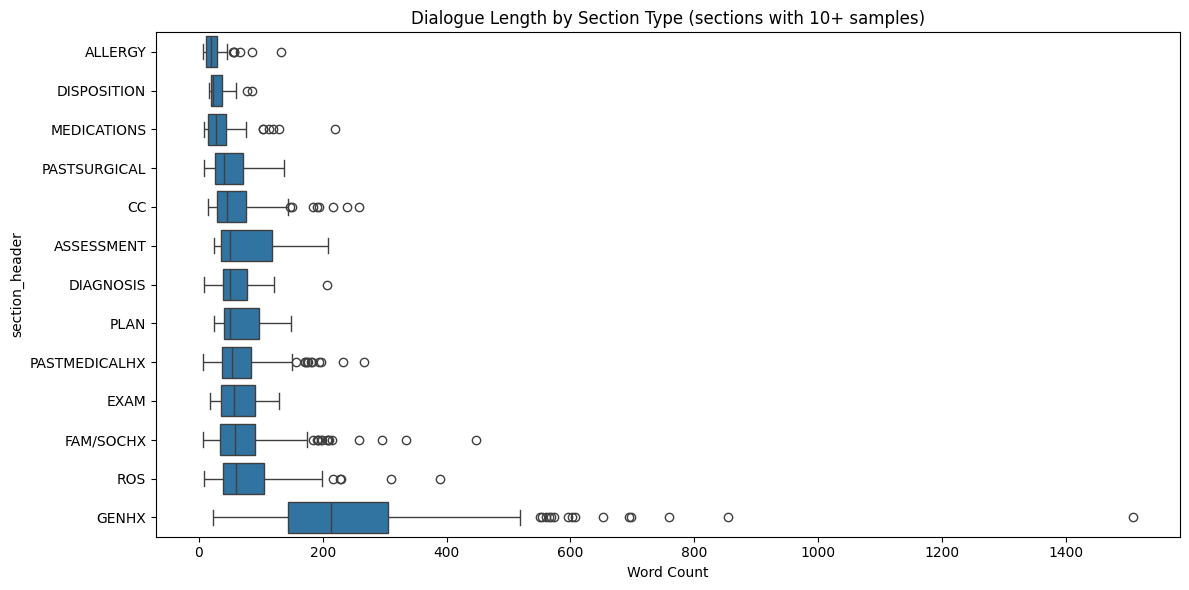

In [ ]:
import seaborn as sns

#only plot sections with enough samples to be meaningfule, so 10+ here
top_sections = train_df['section_header'].value_counts()
top_sections = top_sections[top_sections >= 10].index

filtered = train_df[train_df['section_header'].isin(top_sections)]

fig, ax = plt.subplots(figsize=(12, 6))
sns.boxplot(data=filtered, x='dialogue_word_count', y='section_header',
            order=filtered.groupby('section_header')['dialogue_word_count'].median().sort_values().index,
            ax=ax)
ax.set_title('Dialogue Length by Section Type (sections with 10+ samples)')
ax.set_xlabel('Word Count')
plt.tight_layout()
plt.show()

In [13]:
#look at some examples across diff section types
for section in ['CC', 'ASSESSMENT', 'GENHX', 'MEDICATIONS', 'PLAN']:
    samples = train_df[train_df['section_header'] == section].head(2)
    print(f"\n{'='*60}")
    print(f"SECTION: {section}")
    print(f"{'='*60}")
    for _, row in samples.iterrows():
        print(f"\nNote: {row['section_text'][:200]}")
        print(f"---")


SECTION: CC

Note: Burn, right arm.
---

Note: Intractable nausea and vomiting.
---

SECTION: ASSESSMENT

Note: 1.  Hypoglycemia due to not eating her meals on a regular basis. 2.  Hypertension. 3.  Renal insufficiency, may be dehydration, or diabetic nephropathy.
---

Note: Blood-borne pathogen exposure secondary to contaminated needlestick.
---

SECTION: GENHX

Note: The patient is a 76-year-old white female who presents to the clinic today originally for hypertension and a med check.  She has a history of hypertension, osteoarthritis, osteoporosis, hypothyroidism
---

Note: The patient is a 25-year-old right-handed Caucasian female who presented to the emergency department with sudden onset of headache occurring at approximately 11 a.m. on the morning of the July 31, 200
---

SECTION: MEDICATIONS

Note: Prescribed medications were Salmeterol inhaler, prn; and Fluticasone nasal inhaler. The patient was taking no over the counter or alternative medicines.
---

Note: None.
---

SECTIO

In [14]:
#consolidate the rare sections into broader categories
section_mapping = {
    'GENHX': 'History',
    'FAM/SOCHX': 'History',
    'PASTMEDICALHX': 'History',
    'PASTSURGICAL': 'History',
    'OTHER_HISTORY': 'History',
    'GYNHX': 'History',
    'CC': 'Chief Complaint',
    'ROS': 'Exam/Review',
    'EXAM': 'Exam/Review',
    'ALLERGY': 'Medications/Allergies',
    'MEDICATIONS': 'Medications/Allergies',
    'IMMUNIZATIONS': 'Medications/Allergies',
    'ASSESSMENT': 'Assessment/Diagnosis',
    'DIAGNOSIS': 'Assessment/Diagnosis',
    'PLAN': 'Plan/Disposition',
    'DISPOSITION': 'Plan/Disposition',
    'EDCOURSE': 'Plan/Disposition',
    'PROCEDURES': 'Plan/Disposition',
    'IMAGING': 'Plan/Disposition',
    'LABS': 'Plan/Disposition',
}

train_df['section_group'] = train_df['section_header'].map(section_mapping)

print("Grouped section counts:\n")
print(train_df['section_group'].value_counts())

Grouped section counts:

section_group
History                  821
Medications/Allergies    122
Exam/Review               83
Chief Complaint           77
Assessment/Diagnosis      53
Plan/Disposition          45
Name: count, dtype: int64


## EDA Summary

**Dataset:** MTS-Dialog — 1,201 training pairs, 100 validation pairs

**Key findings:**
- Each dialogue maps to exactly 1 clinical note section (1,199 unique dialogues)
- Dialogues are short: median 64 words, 6 turns
- Notes are very concise: median 14 words
- 20 section types, heavily skewed toward FAM/SOCHX and GENHX
- Dialogue length varies significantly by section type (strong feature)
- Grouped 20 sections into 6 borader categories for classification